Laboratorio 3, Fisica Computacional

Juan Manuel Patiño Daza

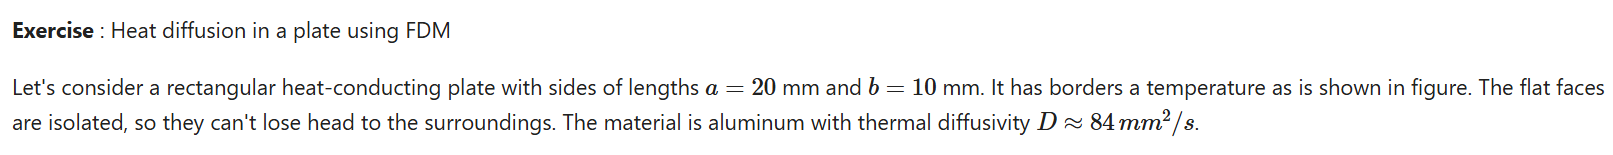

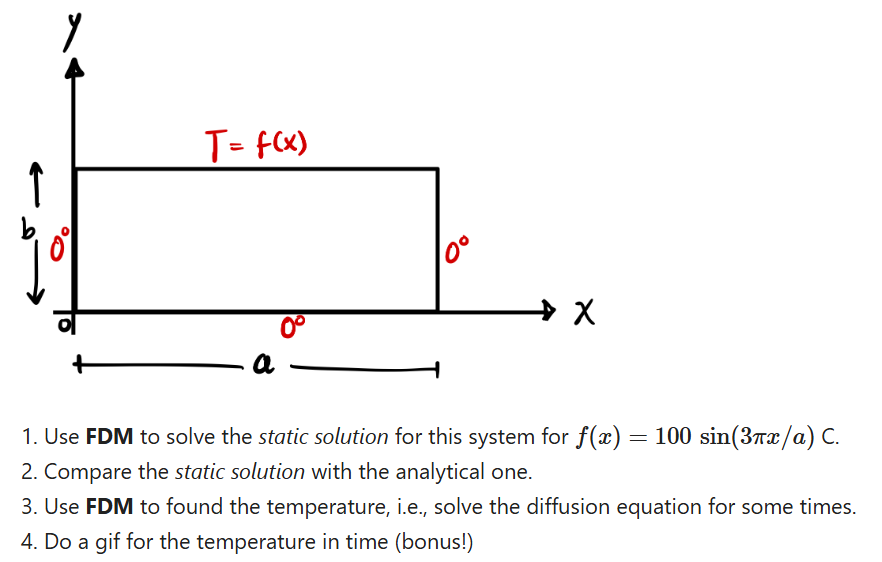

#Problema 1

In [1]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt
from numba import njit

In [2]:
@njit  #este decorador solamente va a hacer que no esperemos mas de 2 segundos al ejecutar estas funciones
def Laplace2D_FDM(V_ini,Niter):
  'Int the V initial configutaration.\n Niter is the number of the iterations of the algorithm. Return V_out Laplace case.'

  nx,ny = V_ini.shape
  V = V_ini.copy()
  conv = np.zeros((nx, ny), float)

  iter = 0

  while iter <= Niter:
    iter+=1
    for i in range(1, nx-1):
      for j in range(1,ny-1):
        conv[i,j] = V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1] - 4*V[i,j]
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])

    V[0, :] = 0.0
    V[nx - 1, :] = 0.0
    V[:, 0] = 0.0

    for k in range(nx):
        V[k, ny - 1] = 100.0 * np.sin(3.0 * np.pi * k / (nx - 1))

    if np.max(np.abs(conv)) <= 1e-4:
      print(iter)
      print(np.max(conv))
      break

  return V

In [3]:
def grid(V_ini,x,y):
  'to compute x,y,z'
  V = V_ini.copy()
  X, Y = np.meshgrid(x,y)
  Z = V[X,Y] #filed value
  return X,Y,Z

101
9.720194687901085e-05


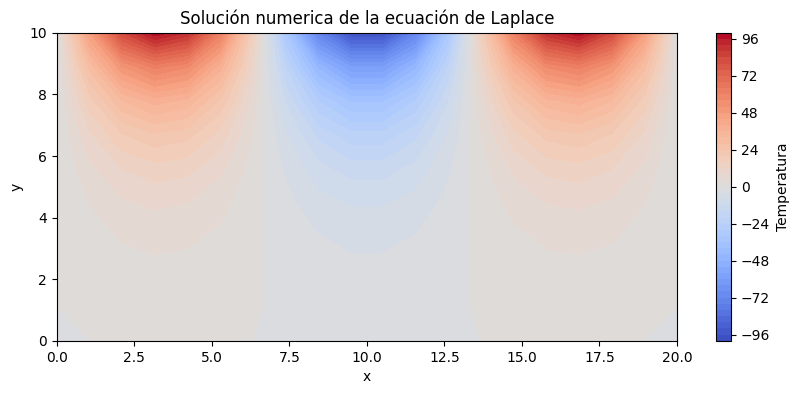

In [11]:
Nmax, Niter = 100, 8000
a = 20 #mm 0<x<a
b = 10 #mm 0<y<b


# Initial V matrix
V_ini = np.zeros((a, b), float)

for k in range(a):
    V_ini[k, b - 1] = 100.0 * np.sin(3.0 * np.pi * k / (a - 1))

# Do the grid to plot
x = np.linspace(0, a , a)
y = np.linspace(0, b , b)

X, Y = np.meshgrid(y, x)  # Forma estándar de SciPy/NumPy para 3D

V = Laplace2D_FDM(V_ini, Niter)


plt.figure(figsize=(10,4))
plt.contourf(Y, X, V, levels=50,cmap='coolwarm')
plt.colorbar(label="Temperatura")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Solución numerica de la ecuación de Laplace")
plt.show()

Aqui hacemos uso de el codigo visto en la clase pasada puest que como nos dicen el caso estatico entonces dt=0, usando la misma funcion ya vista modificando las condiciones de frontera nos queda la solucion anterior.

##Problema 2

###Solución Analítica: Ecuación de Laplace 2D por Separación de Variables

Para encontrar la solución estática ($\partial T / \partial t = 0$) del sistema en la placa rectangular con dimensiones $a = 20\text{ mm}$ y $b = 10\text{ mm}$, resolvemos la **ecuación de Laplace**:

$$\nabla^2 \phi(x,y) = \frac{\partial^2 \phi}{\partial x^2} + \frac{\partial^2 \phi}{\partial y^2} = 0$$

Sujeta a las siguientes condiciones de frontera de Dirichlet:
1. $\phi(0, y) = 0$
2. $\phi(a, y) = 0$
3. $\phi(x, 0) = 0$
4. $\phi(x, b) = f(x) = 100 \sin\left(\frac{3\pi x}{a}\right)$

---

#### 1. Propuesta de Separación de Variables
Proponemos una solución de la forma $\phi(x,y) = A(x)B(y)$. Sustituyendo en la ecuación diferencial:

$$\frac{1}{A(x)} \frac{d^2 A}{d x^2} + \frac{1}{B(y)} \frac{d^2 B}{d y^2} = 0$$

Igualamos ambas partes a una constante de separación $-\alpha^2$:

$$\frac{1}{A} \frac{d^2 A}{dx^2} = -\alpha^2 \implies \frac{d^2 A}{dx^2} + \alpha^2 A = 0$$

$$\frac{1}{B} \frac{d^2 B}{dy^2} = \alpha^2 \implies \frac{d^2 B}{dy^2} - \alpha^2 B = 0$$

---

#### 2. Solución para $A(x)$
La ecuación diferencial ordinaria para $A(x)$ tiene solución general en términos de exponenciales complejas o funciones trigonométricas:

$$A(x) = K_1 e^{i\alpha x} + K_2 e^{-i\alpha x}$$

Aplicando las condiciones de frontera para $x$:
* **Para $x = 0$:** $A(0) = K_1 + K_2 = 0 \implies K_2 = -K_1$
  $$A(x) = K_1 \left(e^{i\alpha x} - e^{-i\alpha x}\right) = 2i K_1 \sin(\alpha x) = K' \sin(\alpha x)$$

* **Para $x = a$:** $A(a) = K' \sin(\alpha a) = 0 \implies \alpha a = n\pi$

Por lo tanto, los valores propios son:
$$\alpha = \frac{n\pi}{a}, \quad n \in \mathbb{Z}^+$$

---

#### 3. Solución para $B(y)$
La ecuación diferencial ordinaria para $B(y)$ es:

$$\frac{d^2 B}{dy^2} - \alpha^2 B = 0 \implies B(y) = f_1 e^{\alpha y} + f_2 e^{-\alpha y}$$

Aplicando las condiciones de frontera para $y$:
* **Para $y = 0$:** $B(0) = f_1 + f_2 = 0 \implies f_2 = -f_1$
  $$B(y) = f_1 \left(e^{\alpha y} - e^{-\alpha y}\right) = 2 f_1 \sinh(\alpha y)$$

---

#### 4. Solución General y Borde Superior
Combinando ambas soluciones para un $n$ determinado:

$$\phi(x,y) = C_n \sin\left(\frac{n\pi x}{a}\right) \sinh\left(\frac{n\pi y}{a}\right)$$

Aplicando la condición en el borde superior $\phi(x,b) = f(x) = 100 \sin\left(\frac{3\pi x}{a}\right)$:

$$C_n \sin\left(\frac{n\pi x}{a}\right) \sinh\left(\frac{n\pi b}{a}\right) = 100 \sin\left(\frac{3\pi x}{a}\right)$$

Por comparación directa de los argumentos de la función seno, identificamos que **$n = 3$**:

$$C_3 \sinh\left(\frac{3\pi b}{a}\right) = 100 \implies C_3 = \frac{100}{\sinh\left(\frac{3\pi b}{a}\right)}$$

---

#### 5. Solución Analítica Exacta Final

$$\phi(x,y) = 100 \sin\left(\frac{3\pi x}{a}\right) \left[ \frac{\sinh\left(\frac{3\pi y}{a}\right)}{\sinh\left(\frac{3\pi b}{a}\right)} \right]$$

O expresada en su forma exponencial equivalente:

$$\phi(x,y) = 100 \sin\left(\frac{3\pi x}{a}\right) \left[ \frac{e^{\frac{3\pi y}{a}} - e^{-\frac{3\pi y}{a}}}{e^{\frac{3\pi b}{a}} - e^{-\frac{3\pi b}{a}}} \right]$$

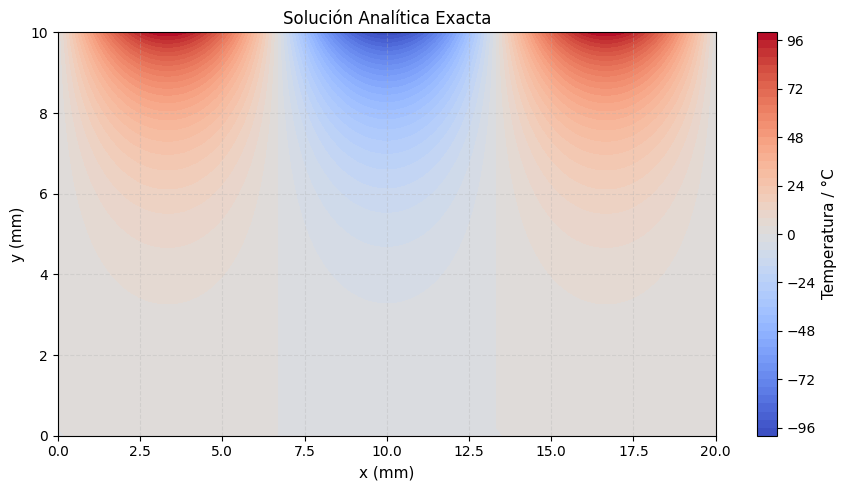

In [5]:
# 1. Parámetros del problema
a = 20.0  # mm (0 < x < a)
b = 10.0  # mm (0 < y < b)
n = 3

nx, ny = 100, 50
x = np.linspace(0, a, nx)
y = np.linspace(0, b, ny)
X, Y = np.meshgrid(x, y)

# 3. Solución analítica exacta

term_x = np.sin(n * np.pi * X / a)
term_y = np.sinh(n * np.pi * Y / a) / np.sinh(n * np.pi * b / a)

phi = 100.0 * term_x * term_y

# 4. Graficación 2D (Contorno de temperatura)
plt.figure(figsize=(9, 5))
contour = plt.contourf(X, Y, phi, levels=50, cmap='coolwarm')

cbar = plt.colorbar(contour)
cbar.set_label("Temperatura / °C", fontsize=11)

plt.xlabel("x (mm)", fontsize=11)
plt.ylabel("y (mm)", fontsize=11)
plt.title(f"Solución Analítica Exacta", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

colocando la solucion anterior obtenemos un grafico muy similar al de el punto 1

##Problema 3

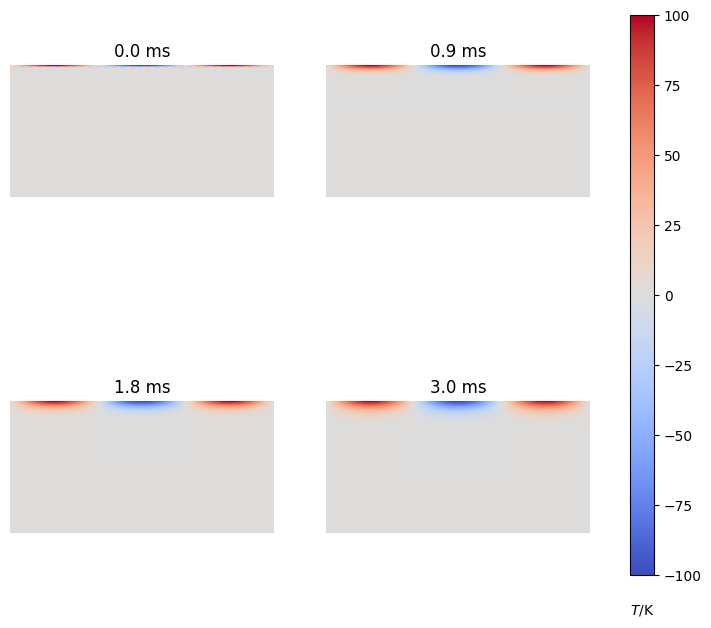

In [10]:
b = 10
a = 20

dx = dy = 0.1
D = 84.0

Tcool, Thot = 0, 100

nx, ny = int(a/dx), int(b/dy)

dx2, dy2 = dx*dx, dy*dy
dt = dx2*dy2/(2*D*(dx2 + dy2)) #maximun t allowed

u0 = Tcool * np.ones((nx, ny)) #init grid (100x100) in 300K
u = u0.copy()

for k in range(int(nx)):
    u0[k, ny-1] = 100.0 * np.sin(3.0 * np.pi * k / (a - 1))

def do_timestep(u0, u):
    # Propagación en el interior
    u[1:-1, 1:-1] = u0[1:-1, 1:-1] + D * dt * (
        u0[2:, 1:-1] - 4 * u0[1:-1, 1:-1] + u0[:-2, 1:-1] + u0[1:-1, 2:] + u0[1:-1, :-2]
    ) / dx2

    # 3. Mantener bordes a 0 C
    u[0, :] = 0.0
    u[-1, :] = 0.0
    u[:, 0] = 0.0

    # Mantener borde superior sinusoidal
    for k in range(nx):
        u[k, ny - 1] = 100.0 * np.sin(3.0 * np.pi * k / (nx - 1))

    u0 = u.copy()
    return u0, u

# Number of timesteps.
nsteps = 101
# Output 4 figures at these timesteps.
mfig = [0, 30, 60, 100]
fignum = 0
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,8) )
for m in range(nsteps):
    u0, u = do_timestep(u0, u)
    if m in mfig:
        #print(m, fignum)
        ax = axes[fignum // 2, fignum % 2]
        im = ax.imshow(
          u.T,                  # Matriz ajustada (10x20)
          cmap="coolwarm",      # Permite ver temperaturas negativas (azul) y positivas (rojo)
          vmin=-100.0,
          vmax=100.0,
          origin="lower",       # Coloca y=0 abajo y el borde caliente arriba
          extent=[0, a, 0, b]   # Define los ejes reales en mm
        )
        ax.set_axis_off()
        ax.set_title("{:.1f} ms".format(m*dt*1000))
        fignum += 1

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$/K", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

En este problema hacemos uso de la ecuacion de difion vista en clase, solo cambian las condiciones de frontera y la forma en la que se genera la malla inicial por las condiciones de frontera

In [7]:
! pip install celluloid
#el codigo posterior a este bloque fue hecho con gemini:

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
from IPython.display import HTML

# ==========================================
# 1. PARÁMETROS FÍSICOS Y GEOMÉTRICOS
# ==========================================
a, b = 20.0, 10.0      # Dimensiones de la placa en mm
dx = dy = 0.1          # Paso espacial en mm
D = 84.0               # Difusividad térmica del aluminio (mm^2/s)

# Tamaño de la malla discreta
nx, ny = int(a / dx), int(b / dy)

# Paso temporal basado en la condición de estabilidad Neumann (CFL 2D)
dx2, dy2 = dx * dx, dy * dy
dt = dx2 * dy2 / (2.0 * D * (dx2 + dy2))

# ==========================================
# 2. CONDICIONES INICIALES Y DE FRONTERA
# ==========================================
u0 = np.zeros((nx, ny))  # Matriz inicial a 0 °C

# Aplicar término fuente sinusoidal en el borde superior (y = b, índice ny - 1)
for k in range(nx):
    u0[k, ny - 1] = 100.0 * np.sin(3.0 * np.pi * k / (nx - 1))

u = u0.copy()

# ==========================================
# 3. FUNCIÓN DE PROPAGACIÓN TEMPORAL (FDM)
# ==========================================
def do_timestep(u_prev, u_curr):
    # Diferencias finitas en el interior (Forward en tiempo, Centrada en espacio)
    u_curr[1:-1, 1:-1] = u_prev[1:-1, 1:-1] + D * dt * (
        u_prev[2:, 1:-1] - 4.0 * u_prev[1:-1, 1:-1] + u_prev[:-2, 1:-1] +
        u_prev[1:-1, 2:] + u_prev[1:-1, :-2]
    ) / dx2

    # Mantener bordes fijos a 0 °C (Dirichlet)
    u_curr[0, :] = 0.0
    u_curr[-1, :] = 0.0
    u_curr[:, 0] = 0.0

    # Mantener condición en el borde superior (y = b)
    for k in range(nx):
        u_curr[k, ny - 1] = 100.0 * np.sin(3.0 * np.pi * k / (nx - 1))

    return u_curr.copy(), u_curr

# ==========================================
# 4. CONFIGURACIÓN DE LA ANIMACIÓN
# ==========================================
fig, ax = plt.subplots(figsize=(8, 4.5))
camera = Camera(fig)

# Crear imagen base para fijar la colorbar de forma estética
im_dummy = ax.imshow(
    u.T, cmap="coolwarm", vmin=-100.0, vmax=100.0, origin="lower", extent=[0, a, 0, b]
)
cbar = fig.colorbar(im_dummy, ax=ax)
cbar.set_label("Temperatura / °C")

nsteps = 250       # Número total de pasos en el tiempo
frame_step = 5     # Capturar 1 fotograma cada 5 iteraciones

for m in range(nsteps):
    u0, u = do_timestep(u0, u)

    if m % frame_step == 0:
        # Transpuesta (u.T) para orientar a=20mm en X y b=10mm en Y
        ax.imshow(
            u.T,
            cmap="coolwarm",
            vmin=-100.0,
            vmax=100.0,
            origin="lower",
            extent=[0, a, 0, b]
        )
        ax.set_title(f"Difusión de Calor 2D  = {m * dt * 1000:.2f} ms")
        ax.set_xlabel("x (mm)")
        ax.set_ylabel("y (mm)")

        # Guardar fotograma
        camera.snap()

# Compilar animación y generar GIF/reproductor HTML
animation = camera.animate(interval=60)
animation.save("difusion_calor_2d.gif", writer="pillow")
plt.close(fig)

# Mostrar directamente en el Jupyter Notebook
HTML(animation.to_jshtml())